# Notebook 4: Bảng so sánh & trực quan hóa kết quả

**Đầu vào (sau khi chạy NB3):**
- `data/kmeans_init_comparison.csv` — SSE, Silhouette, Davies–Bouldin, số vòng lặp.
- `data/rfm_with_kmeans_clusters.csv` — RFM gốc + nhãn cụm theo từng phương pháp.

**Nội dung:**
1. Bảng so sánh phương pháp (có ghi chú hướng tốt cho từng chỉ số).
2. Bốn biểu đồ **thanh ngang** so từng metric (dễ đọc, không ghép hai trục Y).
3. **Phân khúc chính** dùng cột `kmeans_gms_afkmc2_pipeline` (pipeline GMS + AFK-MC2 sub + K-means full): cỡ cụm, trung bình/trung vị RFM, heatmap, boxplot, PCA-2D.
4. Hình lưu vào thư mục `figures/` (PNG) để chèn vào báo cáo.

**Cài thêm:** `python3 -m pip install seaborn` (đã có trong `requirements.txt`).

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

# Phông chữ (tiếng Việt): nếu lỗi hiển thị dấu, đổi sang font có sẵn trên máy bạn
plt.rcParams["font.family"] = ["DejaVu Sans", "Arial Unicode MS", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", context="notebook")

def _project_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / "requirements.txt").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    return Path.cwd().resolve()


ROOT = _project_root()
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

METRICS_PATH = DATA_DIR / "kmeans_init_comparison.csv"
RFM_CLUSTERS_PATH = DATA_DIR / "rfm_with_kmeans_clusters.csv"

# Cột cụm dùng cho phân tích nghiệp vụ (pipeline theo paper)
PRIMARY_CLUSTER_COL = "kmeans_gms_afkmc2_pipeline"

CLUSTER_METHOD_LABELS = {
    "kmeans_gms_afkmc2_pipeline": "GMS + AFK-MC2(sub) + K-means",
    "kmeans_afkmc2_full": "AFK-MC2(full) + K-means",
    "kmeans_pp": "K-means++",
    "kmeans_random": "K-means (random)",
}

# Tên cột ngắn cho heatmap / trục (đồ thị)
METHOD_COL_SHORT_PLOT = {
    "GMS + AFK-MC2(sub) + K-means": "GMS+AFK→K",
    "AFK-MC2(full) + K-means": "AFK full",
    "K-means++": "K++",
    "K-means (random)": "Random",
}

RANDOM_STATE = 42

In [2]:
def save_fig(name: str) -> Path:
    path = FIG_DIR / name
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Đã lưu:", path.resolve())
    return path


if not METRICS_PATH.is_file() or not RFM_CLUSTERS_PATH.is_file():
    raise FileNotFoundError(
        "Thiếu file kết quả. Hãy chạy xong 03_AFKMC2.ipynb để tạo:\n"
        f"  - {METRICS_PATH}\n  - {RFM_CLUSTERS_PATH}"
    )

## 1. Bảng so sánh phương pháp (từ NB3)

- **SSE (inertia):** càng **nhỏ** càng tốt (sai số trong cụm nhỏ hơn).  
- **Silhouette:** càng **cao** càng tốt (thường trong \([-1, 1]\), gần 1 là tách cụm rõ).  
- **Davies–Bouldin (sklearn):** càng **nhỏ** càng tốt.  
- **n_iter:** số vòng Lloyd sau khởi tạo — nhỏ hơn thường có nghĩa hội tụ nhanh hơn (cùng điều kiện dừng).

In [3]:
metrics_df = pd.read_csv(METRICS_PATH)
display_cols = ["method", "SSE_inertia", "silhouette", "davies_bouldin", "n_iter"]
tbl = metrics_df[display_cols].copy()
tbl = tbl.round({"SSE_inertia": 4, "silhouette": 6, "davies_bouldin": 6})

# Đánh dấu tốt nhất theo từng cột (để in kèm bảng trong báo cáo)
best_sse = tbl.loc[tbl["SSE_inertia"].idxmin(), "method"]
best_sil = tbl.loc[tbl["silhouette"].idxmax(), "method"]
best_db = tbl.loc[tbl["davies_bouldin"].idxmin(), "method"]
best_iter = tbl.loc[tbl["n_iter"].idxmin(), "method"]

summary_lines = [
    f"Tốt nhất SSE: **{best_sse}**",
    f"Tốt nhất Silhouette: **{best_sil}**",
    f"Tốt nhất Davies–Bouldin (nhỏ nhất): **{best_db}**",
    f"Ít vòng lặp nhất: **{best_iter}**",
]
print("\n".join(summary_lines))

tbl

Tốt nhất SSE: **GMS + AFK-MC2 (sub) + K-means (full)**
Tốt nhất Silhouette: **AFK-MC2 (full) + K-means**
Tốt nhất Davies–Bouldin (nhỏ nhất): **GMS + AFK-MC2 (sub) + K-means (full)**
Ít vòng lặp nhất: **GMS + AFK-MC2 (sub) + K-means (full)**


,method,SSE_inertia,silhouette,davies_bouldin,n_iter
0,GMS + AFK-MC2 (sub) + K-means (full),4468.9147,0.361583,0.891984,6
1,AFK-MC2 (full) + K-means,4785.2520,0.384365,0.927945,16
2,K-means++,4469.0065,0.361398,0.893440,16
3,K-means (random init),4468.9611,0.361472,0.892792,12


In [4]:
# Xuất bảng ra CSV/HTML tùy chọn (để dán Word/LaTeX)
tbl.to_csv(DATA_DIR / "bang_so_sanh_phuong_phap.csv", index=False)
print("CSV:", (DATA_DIR / "bang_so_sanh_phuong_phap.csv").resolve())

CSV: /Users/kotori/GMS_AFKMC2/data/bang_so_sanh_phuong_phap.csv


## 2. So sánh metric — **bốn biểu đồ riêng** (dễ đọc)

Mỗi chỉ số một đồ thị **một trục**; trục dọc là **tên phương pháp rút gọn** (đầy đủ trong bảng phía trên). Thanh **viền xanh** = giá trị tốt nhất theo hướng tối ưu (SSE/DB/n_iter nhỏ nhất; Silhouette lớn nhất).

Đã lưu: /Users/kotori/GMS_AFKMC2/figures/so_sanh_metric_phuong_phap.png


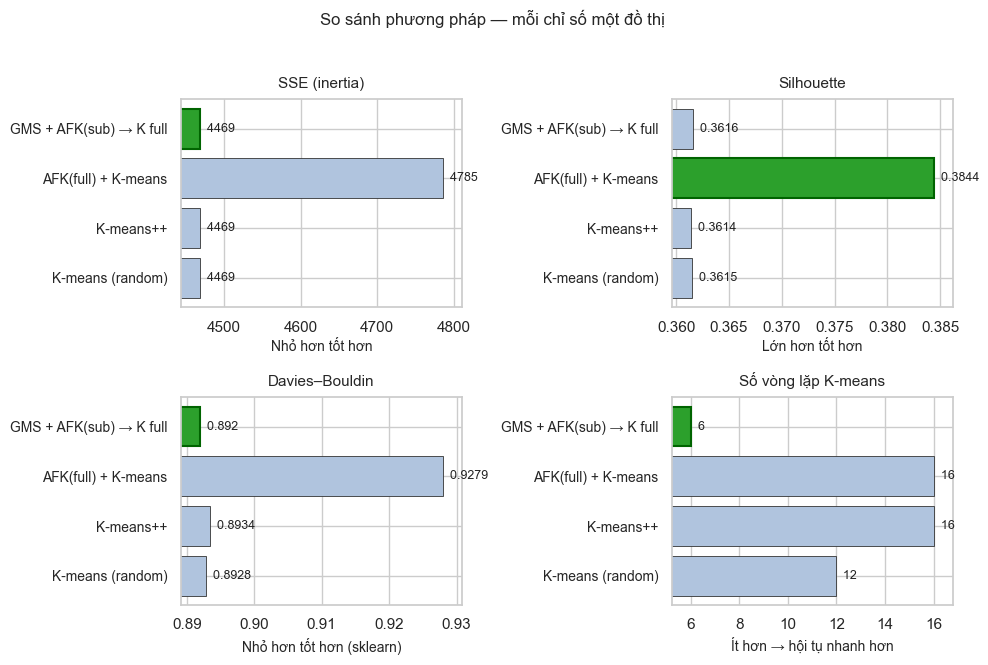

In [5]:
# Tên rút gọn (trục Y) — khớp đúng chuỗi trong CSV từ NB3
METHOD_SHORT = {
    "GMS + AFK-MC2 (sub) + K-means (full)": "GMS + AFK(sub) → K full",
    "AFK-MC2 (full) + K-means": "AFK(full) + K-means",
    "K-means++": "K-means++",
    "K-means (random init)": "K-means (random)",
}


def hbar_metric(ax, values, ylabels, title, xlabel, best="min"):
    y = np.arange(len(values))
    bars = ax.barh(y, values, color="#b0c4de", edgecolor="#333333", linewidth=0.6)
    if best == "min":
        i_star = int(np.argmin(values))
    else:
        i_star = int(np.argmax(values))
    bars[i_star].set_facecolor("#2ca02c")
    bars[i_star].set_edgecolor("#006400")
    bars[i_star].set_linewidth(1.5)
    ax.set_yticks(y)
    ax.set_yticklabels(ylabels, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel(xlabel, fontsize=10)
    lo, hi = float(np.min(values)), float(np.max(values))
    pad = (hi - lo) * 0.08 + (1e-6 if hi == lo else 0)
    ax.set_xlim(lo - pad, hi + pad)
    for yi, v in zip(y, values):
        ax.text(v, yi, f"  {v:.4g}", va="center", fontsize=9, color="#222")

md = metrics_df.copy()
ylabels = [METHOD_SHORT.get(m, m[:40]) for m in md["method"].tolist()]

fig, axes = plt.subplots(2, 2, figsize=(10, 6.5))
fig.suptitle("So sánh phương pháp — mỗi chỉ số một đồ thị", fontsize=12, y=1.02)

hbar_metric(
    axes[0, 0],
    md["SSE_inertia"].to_numpy(),
    ylabels,
    "SSE (inertia)",
    "Nhỏ hơn tốt hơn",
    best="min",
)
hbar_metric(
    axes[0, 1],
    md["silhouette"].to_numpy(),
    ylabels,
    "Silhouette",
    "Lớn hơn tốt hơn",
    best="max",
)
hbar_metric(
    axes[1, 0],
    md["davies_bouldin"].to_numpy(),
    ylabels,
    "Davies–Bouldin",
    "Nhỏ hơn tốt hơn (sklearn)",
    best="min",
)
hbar_metric(
    axes[1, 1],
    md["n_iter"].to_numpy().astype(float),
    ylabels,
    "Số vòng lặp K-means",
    "Ít hơn → hội tụ nhanh hơn",
    best="min",
)

plt.tight_layout()
save_fig("so_sanh_metric_phuong_phap.png")
plt.show()

## 3. Phân khúc khách hàng (pipeline chính: `kmeans_gms_afkmc2_pipeline`)

Bảng **cỡ cụm**, **% khách**, **trung bình / trung vị** R, F, M (giá trị RFM **gốc**, không phải z-score).

In [6]:
rfm = pd.read_csv(RFM_CLUSTERS_PATH)
if PRIMARY_CLUSTER_COL not in rfm.columns:
    raise KeyError(f"Thiếu cột {PRIMARY_CLUSTER_COL} trong {RFM_CLUSTERS_PATH}")

n_total = len(rfm)
grp = rfm.groupby(PRIMARY_CLUSTER_COL, observed=True)

profile = grp.agg(
    so_khach=("customer_id", "count"),
    R_tb=("R", "mean"),
    R_med=("R", "median"),
    F_tb=("F", "mean"),
    F_med=("F", "median"),
    M_tb=("M", "mean"),
    M_med=("M", "median"),
).reset_index().rename(columns={PRIMARY_CLUSTER_COL: "cum"})

profile["phan_tram"] = (100 * profile["so_khach"] / n_total).round(2)
profile = profile.sort_values("cum")

# Làm đẹp số để hiển thị / xuất
prof_out = profile.copy()
for c in ["R_tb", "R_med", "F_tb", "F_med"]:
    prof_out[c] = prof_out[c].round(2)
prof_out["M_tb"] = prof_out["M_tb"].round(2)
prof_out["M_med"] = prof_out["M_med"].round(2)

prof_out.to_csv(DATA_DIR / "bang_profile_rfm_theo_cum.csv", index=False)
print("CSV:", (DATA_DIR / "bang_profile_rfm_theo_cum.csv").resolve())
prof_out

CSV: /Users/kotori/GMS_AFKMC2/data/bang_profile_rfm_theo_cum.csv


,cum,so_khach,R_tb,R_med,F_tb,F_med,M_tb,M_med,phan_tram
0,0,1391,104.96,71.0,1.74,2.0,428.08,374.70,23.66
1,1,1892,97.33,54.5,5.50,5.0,1925.45,1604.84,32.19
2,2,1641,492.27,462.0,1.73,1.0,539.84,339.34,27.92
3,3,954,41.51,17.0,22.35,15.0,13227.60,6355.18,16.23


Đã lưu: /Users/kotori/GMS_AFKMC2/figures/ty_le_khach_theo_cum.png


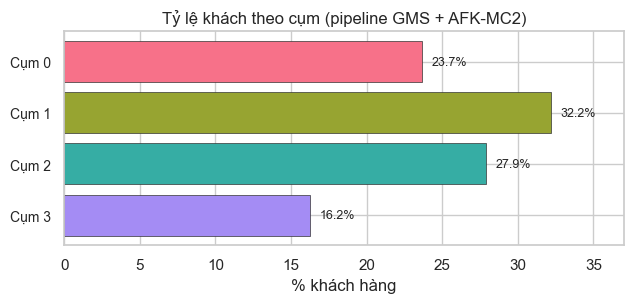

In [7]:
# Thanh ngang: % khách theo cụm (dễ đọc hơn cột dọc + nhãn dài)
fig, ax = plt.subplots(figsize=(6.5, 3.2))
y_labels = ["Cụm " + str(c) for c in prof_out["cum"]]
y_pos = np.arange(len(prof_out))
colors = sns.color_palette("husl", len(prof_out))
ax.barh(y_pos, prof_out["phan_tram"], color=colors, edgecolor="#333", linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("% khách hàng")
ax.set_title("Tỷ lệ khách theo cụm (pipeline GMS + AFK-MC2)")
xmax = prof_out["phan_tram"].max()
ax.set_xlim(0, xmax * 1.15)
for yi, p in zip(y_pos, prof_out["phan_tram"]):
    ax.text(p + xmax * 0.02, yi, f"{p:.1f}%", va="center", fontsize=9)
plt.tight_layout()
save_fig("ty_le_khach_theo_cum.png")
plt.show()

Đã lưu: /Users/kotori/GMS_AFKMC2/figures/heatmap_rfm_tb_theo_cum.png


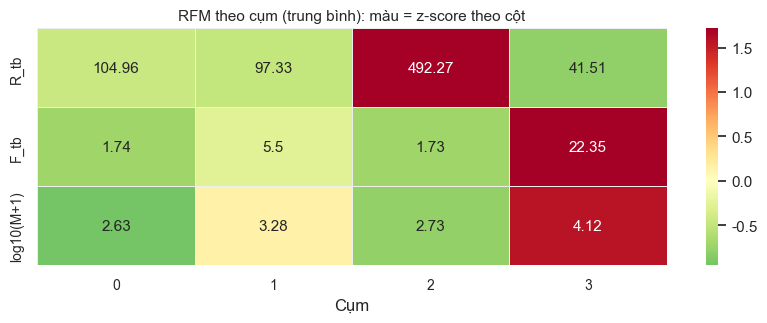

In [8]:
# Heatmap: TB R, F và log10(M+1) theo cụm — màu = z-score theo cột; số trong ô = giá trị thật (R,F, log10(M+1))
heat = profile.set_index("cum")[["R_tb", "F_tb", "M_tb"]].copy()
heat_display = heat.copy()
heat_display["log10(M+1)"] = np.log10(heat_display["M_tb"] + 1)
heat_display = heat_display.drop(columns=["M_tb"])
heat_z = (heat_display - heat_display.mean()) / heat_display.std(ddof=0).replace(0, np.nan)
heat_z = heat_z.fillna(0)

annot = heat_display.T.round(2)
fig, ax = plt.subplots(figsize=(8.5, 3.4))
sns.heatmap(
    heat_z.T,
    annot=annot,
    fmt="g",
    cmap="RdYlGn_r",
    center=0,
    ax=ax,
    annot_kws={"size": 11},
    linewidths=0.5,
    linecolor="#eee",
)
ax.set_title("RFM theo cụm (trung bình): màu = z-score theo cột", fontsize=11)
ax.set_xlabel("Cụm")
ax.tick_params(axis="both", labelsize=10)
plt.tight_layout()
save_fig("heatmap_rfm_tb_theo_cum.png")
plt.show()

## 4. Phân bố R, F, M trong từng cụm (boxplot)

**M** dùng **log10(M + 1)** để trục đỡ bị kéo bởi vài khách chi tiêu rất lớn.

/var/folders/v_/617pz6cj0fgdk8cbm7kv5s9r0000gn/T/ipykernel_39678/1955244389.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="Cụm", y=col, ax=ax, palette="pastel", linewidth=0.8)
/var/folders/v_/617pz6cj0fgdk8cbm7kv5s9r0000gn/T/ipykernel_39678/1955244389.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="Cụm", y=col, ax=ax, palette="pastel", linewidth=0.8)
/var/folders/v_/617pz6cj0fgdk8cbm7kv5s9r0000gn/T/ipykernel_39678/1955244389.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="Cụm

Đã lưu: /Users/kotori/GMS_AFKMC2/figures/boxplot_rfm_theo_cum.png


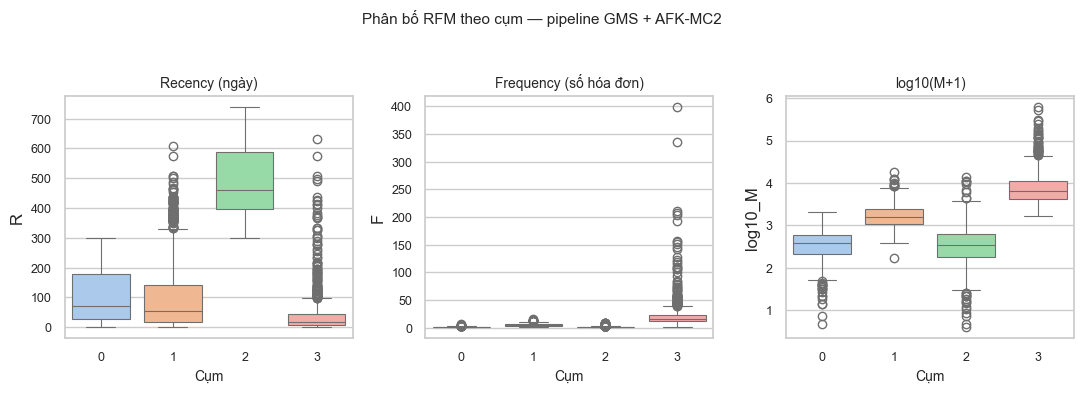

In [9]:
plot_df = rfm[[PRIMARY_CLUSTER_COL, "R", "F", "M"]].copy()
plot_df["log10_M"] = np.log10(plot_df["M"] + 1)
plot_df = plot_df.rename(columns={PRIMARY_CLUSTER_COL: "Cụm"})

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax, col, title in zip(
    axes,
    ["R", "F", "log10_M"],
    ["Recency (ngày)", "Frequency (số hóa đơn)", "log10(M+1)"],
):
    sns.boxplot(data=plot_df, x="Cụm", y=col, ax=ax, palette="pastel", linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Cụm", fontsize=10)
    ax.tick_params(axis="x", labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
plt.suptitle("Phân bố RFM theo cụm — pipeline GMS + AFK-MC2", y=1.03, fontsize=11)
plt.tight_layout()
save_fig("boxplot_rfm_theo_cum.png")
plt.show()

## 5. PCA-2D: cụm pipeline trên không gian R_z, F_z, M_z

Đã lưu: /Users/kotori/GMS_AFKMC2/figures/pca2d_cum_pipeline.png


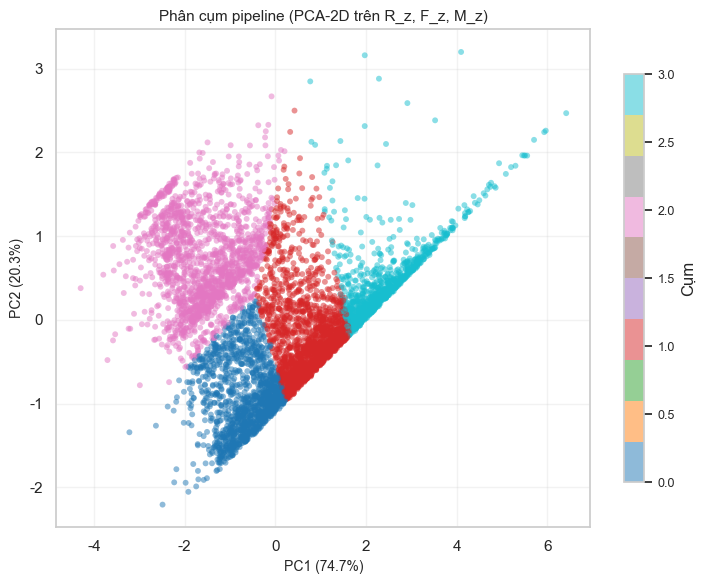

In [10]:
Xz = rfm[["R_z", "F_z", "M_z"]].to_numpy(float)
labels = rfm[PRIMARY_CLUSTER_COL].to_numpy()
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X2 = pca.fit_transform(Xz)

fig, ax = plt.subplots(figsize=(7.5, 6))
sc = ax.scatter(X2[:, 0], X2[:, 1], c=labels, cmap="tab10", alpha=0.5, s=18, edgecolors="none")
cb = plt.colorbar(sc, ax=ax, label="Cụm", shrink=0.82)
cb.ax.tick_params(labelsize=9)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=10)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=10)
ax.set_title("Phân cụm pipeline (PCA-2D trên R_z, F_z, M_z)", fontsize=11)
ax.grid(True, alpha=0.25)
plt.tight_layout()
save_fig("pca2d_cum_pipeline.png")
plt.show()

## 6. So sánh **cơ cấu cụm** giữa các phương pháp (% khách mỗi nhãn)

Mỗi cột là một phương pháp; mỗi hàng là **nhãn cụm** (0…k−1). Ô = % khách trong cụm đó.

CSV: /Users/kotori/GMS_AFKMC2/data/bang_phan_tram_cum_theo_phuong_phap.csv
Đã lưu: /Users/kotori/GMS_AFKMC2/figures/heatmap_co_cau_cum_theo_phuong_phap.png


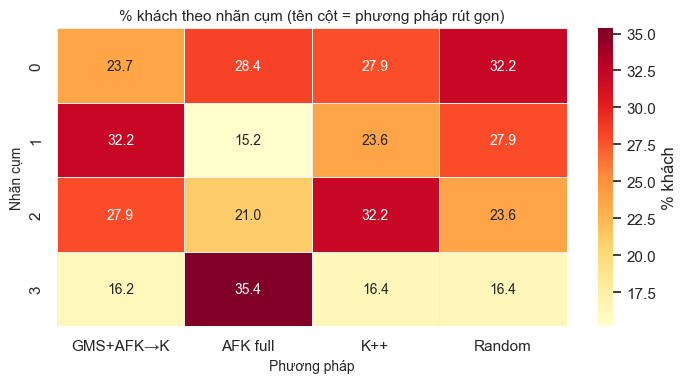

,GMS + AFK-MC2(sub) + K-means,AFK-MC2(full) + K-means,K-means++,K-means (random)
0,23.66,28.39,27.87,32.20
1,32.19,15.21,23.55,27.88
2,27.92,21.04,32.17,23.56
3,16.23,35.35,16.42,16.35


In [11]:
method_cols = [c for c in CLUSTER_METHOD_LABELS if c in rfm.columns]
parts = {}
for col in method_cols:
    vc = rfm[col].value_counts(normalize=True)
    parts[CLUSTER_METHOD_LABELS[col]] = vc
pct_wide = pd.DataFrame(parts).sort_index().fillna(0) * 100
pct_wide = pct_wide.round(2)
pct_wide.to_csv(DATA_DIR / "bang_phan_tram_cum_theo_phuong_phap.csv")
print("CSV:", (DATA_DIR / "bang_phan_tram_cum_theo_phuong_phap.csv").resolve())

# Đồ thị: cột ngắn; file CSV vẫn giữ tên đầy đủ
pct_plot = pct_wide.rename(columns=lambda c: METHOD_COL_SHORT_PLOT.get(c, c))
fig, ax = plt.subplots(figsize=(7.2, 4.0))
sns.heatmap(
    pct_plot,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "% khách"},
    annot_kws={"size": 10},
    linewidths=0.4,
    linecolor="#eee",
)
ax.set_title("% khách theo nhãn cụm (tên cột = phương pháp rút gọn)", fontsize=11)
ax.set_ylabel("Nhãn cụm", fontsize=10)
ax.set_xlabel("Phương pháp", fontsize=10)
plt.tight_layout()
save_fig("heatmap_co_cau_cum_theo_phuong_phap.png")
plt.show()

pct_wide